In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
df = pd.read_csv('Social_Media_Advertising.csv')
print("Shape: ", df.shape)
print("\nFirst look: ")
df.head()

Shape:  (300000, 16)

First look: 


,Campaign_ID,Target_Audience,Campaign_Goal,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Company
0,529013,Men 35-44,Product Launch,15 Days,Instagram,0.15,$500.00,5.790000,Las Vegas,Spanish,500,3000,7,Health,2022-02-25,Aura Align
1,275352,Women 45-60,Market Expansion,15 Days,Facebook,0.01,$500.00,7.210000,Los Angeles,French,500,3000,5,Home,2022-05-12,Hearth Harmony
2,692322,Men 45-60,Product Launch,15 Days,Instagram,0.08,$500.00,0.430000,Austin,Spanish,500,3000,9,Technology,2022-06-19,Cyber Circuit
3,675757,Men 25-34,Increase Sales,15 Days,Pinterest,0.03,$500.00,0.909824,Miami,Spanish,293,1937,1,Health,2022-09-08,Well Wish
4,535900,Men 45-60,Market Expansion,15 Days,Pinterest,0.13,$500.00,1.422828,Austin,French,293,1937,1,Home,2022-08-24,Hearth Harmony


In [5]:
print("=== DATASET INFO ===")
df.info()
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
print("\n=== BASIC STATS ===")
df.describe().round(2)

=== DATASET INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       300000 non-null  int64  
 1   Target_Audience   300000 non-null  str    
 2   Campaign_Goal     300000 non-null  str    
 3   Duration          300000 non-null  str    
 4   Channel_Used      300000 non-null  str    
 5   Conversion_Rate   300000 non-null  float64
 6   Acquisition_Cost  300000 non-null  str    
 7   ROI               300000 non-null  float64
 8   Location          300000 non-null  str    
 9   Language          300000 non-null  str    
 10  Clicks            300000 non-null  int64  
 11  Impressions       300000 non-null  int64  
 12  Engagement_Score  300000 non-null  int64  
 13  Customer_Segment  300000 non-null  str    
 14  Date              300000 non-null  str    
 15  Company           300000 non-null  str    
dtypes: float64

,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
count,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00
mean,550444.80,0.08,3.18,18153.67,56034.24,4.37
std,260252.59,0.04,2.46,11027.02,32583.14,3.16
min,100001.00,0.01,0.00,293.00,1937.00,1.00
25%,325003.50,0.05,0.93,8821.00,28362.00,1.00
50%,551164.50,0.08,2.67,17230.00,54098.00,4.00
75%,776284.50,0.11,5.33,26808.00,80925.25,7.00
max,999998.00,0.15,8.00,40000.00,120000.00,10.00


In [8]:
print("=== UNIQUE VALUES ===")
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

=== UNIQUE VALUES ===
Target_Audience: <StringArray>
[  'Men 35-44', 'Women 45-60',   'Men 45-60',   'Men 25-34', 'Women 35-44',
    'All Ages', 'Women 25-34',   'Men 18-24', 'Women 18-24']
Length: 9, dtype: str
Campaign_Goal: <StringArray>
['Product Launch', 'Market Expansion', 'Increase Sales', 'Brand Awareness']
Length: 4, dtype: str
Duration: <StringArray>
['15 Days', '30 Days', '45 Days', '60 Days']
Length: 4, dtype: str
Channel_Used: <StringArray>
['Instagram', 'Facebook', 'Pinterest', 'Twitter']
Length: 4, dtype: str
Acquisition_Cost: <StringArray>
[  '$500.00',   '$500.10',   '$500.18',   '$500.20',   '$500.27',   '$500.45',
   '$500.49',   '$500.59',   '$500.61',   '$500.66',
 ...
 '$14999.49', '$14999.53', '$14999.61', '$14999.62', '$14999.81', '$14999.92',
 '$14999.96', '$14999.97', '$14999.98', '$15000.00']
Length: 250998, dtype: str
Location: <StringArray>
['Las Vegas', 'Los Angeles', 'Austin', 'Miami', 'New York']
Length: 5, dtype: str
Language: <StringArray>
['Spanish', 

In [9]:
# Fix Acquisition_Cost — remove $ and convert to number
df['Acquisition_Cost'] = df['Acquisition_Cost'].str.replace('$', '').str.replace(',', '').astype(float)

# Fix Date — convert string to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract useful date features
df['Month']      = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Quarter']    = df['Date'].dt.quarter
df['DayOfWeek']  = df['Date'].dt.day_name()

print("Fixed dtypes:")
print(df[['Acquisition_Cost', 'Date', 'Month', 'Quarter']].dtypes)
print("\nAcquisition Cost range:")
print(f"Min: ${df['Acquisition_Cost'].min():,.2f}")
print(f"Max: ${df['Acquisition_Cost'].max():,.2f}")
print(f"Mean: ${df['Acquisition_Cost'].mean():,.2f}")

Fixed dtypes:
Acquisition_Cost           float64
Date                datetime64[us]
Month                        int32
Quarter                      int32
dtype: object

Acquisition Cost range:
Min: $500.00
Max: $15,000.00
Mean: $7,753.75


In [10]:
# CTR = Click Through Rate (how many people clicked vs saw the ad)
df['CTR'] = (df['Clicks'] / df['Impressions'] * 100).round(4)

# CPC = Cost Per Click (how much each click costs)
df['CPC'] = (df['Acquisition_Cost'] / df['Clicks']).round(4)

# Cost Per Impression (how much each view costs)
df['CPM'] = (df['Acquisition_Cost'] / df['Impressions'] * 1000).round(4)

# Revenue estimate (ROI * Cost = Revenue generated)
df['Revenue'] = (df['ROI'] * df['Acquisition_Cost']).round(2)

# High Engagement flag (engagement score above median = 1, else 0)
engagement_median = df['Engagement_Score'].median()
df['High_Engagement'] = (df['Engagement_Score'] > engagement_median).astype(int)

print("New features created:")
print(df[['CTR', 'CPC', 'CPM', 'Revenue', 'High_Engagement']].describe().round(4))
print(f"\nEngagement median: {engagement_median}")
print(f"High engagement campaigns: {df['High_Engagement'].sum():,} ({df['High_Engagement'].mean()*100:.1f}%)")

New features created:
               CTR          CPC          CPM      Revenue  High_Engagement
count  300000.0000  300000.0000  300000.0000  300000.0000      300000.0000
mean       31.4156       0.4558     141.2213   24621.4677           0.4494
std         2.4657       0.1291      31.6526   25740.7816           0.4974
min        15.1187       0.2398      64.9773       0.0000           0.0000
25%        30.1698       0.3800     125.6928    4689.1175           0.0000
50%        32.5373       0.3875     126.5567   14403.4850           0.0000
75%        33.1266       0.5721     130.2083   37673.5075           1.0000
max        33.3333       1.7065     258.1311  120000.0000           1.0000

Engagement median: 4.0
High engagement campaigns: 134,818 (44.9%)


In [11]:
print("=== FINAL DATASET SHAPE ===")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\n=== NEW COLUMNS ADDED ===")
new_cols = ['CTR', 'CPC', 'CPM', 'Revenue', 'Month', 'Quarter', 
            'DayOfWeek', 'High_Engagement']
print(df[new_cols].head())

print("\n=== DATA TYPES ===")
print(df.dtypes)

=== FINAL DATASET SHAPE ===
Rows: 300,000
Columns: 25

=== NEW COLUMNS ADDED ===
       CTR     CPC       CPM  Revenue  Month  Quarter  DayOfWeek  \
0  16.6667  1.0000  166.6667  2895.00      2        1     Friday   
1  16.6667  1.0000  166.6667  3605.00      5        2   Thursday   
2  16.6667  1.0000  166.6667   215.00      6        2     Sunday   
3  15.1265  1.7065  258.1311   454.91      9        3   Thursday   
4  15.1265  1.7065  258.1311   711.41      8        3  Wednesday   

   High_Engagement  
0                1  
1                1  
2                1  
3                0  
4                0  

=== DATA TYPES ===
Campaign_ID                  int64
Target_Audience                str
Campaign_Goal                  str
Duration                       str
Channel_Used                   str
Conversion_Rate            float64
Acquisition_Cost           float64
ROI                        float64
Location                       str
Language                       str
Clicks        

In [12]:
platform_stats = df.groupby('Channel_Used').agg(
    campaigns       = ('Campaign_ID',     'count'),
    avg_ctr         = ('CTR',             'mean'),
    avg_cpc         = ('CPC',             'mean'),
    avg_roi         = ('ROI',             'mean'),
    avg_conversion  = ('Conversion_Rate', 'mean'),
    avg_engagement  = ('Engagement_Score','mean'),
    total_revenue   = ('Revenue',         'sum')
).round(3)

platform_stats['revenue_per_campaign'] = (
    platform_stats['total_revenue'] / platform_stats['campaigns']
).round(2)

print(platform_stats)

              campaigns  avg_ctr  avg_cpc  avg_roi  avg_conversion  \
Channel_Used                                                         
Facebook          75164   32.136    0.388    3.987            0.08   
Instagram         75101   32.132    0.387    4.009            0.08   
Pinterest         75082   29.240    0.660    0.716            0.08   
Twitter           74653   32.158    0.388    4.002            0.08   

              avg_engagement  total_revenue  revenue_per_campaign  
Channel_Used                                                       
Facebook               5.478   2.322261e+09              30895.92  
Instagram              5.508   2.326699e+09              30980.94  
Pinterest              1.000   4.180131e+08               5567.42  
Twitter                5.496   2.319467e+09              31069.98  


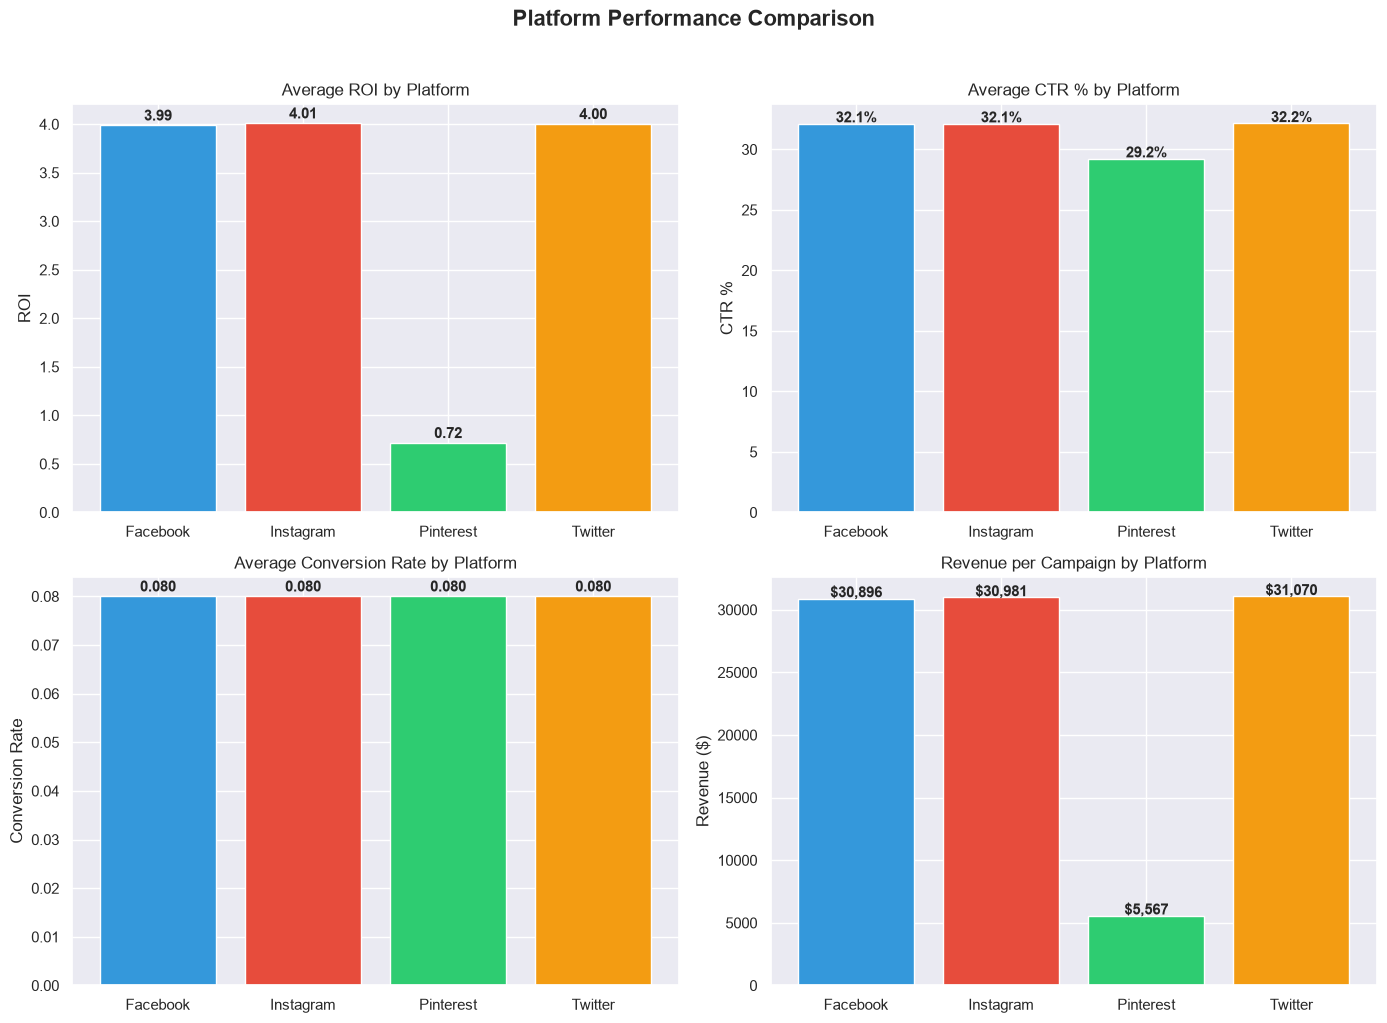

Chart saved!


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Platform Performance Comparison', fontsize=16, fontweight='bold', y=1.02)

platforms = platform_stats.index.tolist()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

# ROI by platform
axes[0,0].bar(platforms, platform_stats['avg_roi'], color=colors)
axes[0,0].set_title('Average ROI by Platform')
axes[0,0].set_ylabel('ROI')
for i, v in enumerate(platform_stats['avg_roi']):
    axes[0,0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

# CTR by platform
axes[0,1].bar(platforms, platform_stats['avg_ctr'], color=colors)
axes[0,1].set_title('Average CTR % by Platform')
axes[0,1].set_ylabel('CTR %')
for i, v in enumerate(platform_stats['avg_ctr']):
    axes[0,1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')

# Conversion Rate by platform
axes[1,0].bar(platforms, platform_stats['avg_conversion'], color=colors)
axes[1,0].set_title('Average Conversion Rate by Platform')
axes[1,0].set_ylabel('Conversion Rate')
for i, v in enumerate(platform_stats['avg_conversion']):
    axes[1,0].text(i, v + 0.001, f'{v:.3f}', ha='center', fontweight='bold')

# Revenue per campaign
axes[1,1].bar(platforms, platform_stats['revenue_per_campaign'], color=colors)
axes[1,1].set_title('Revenue per Campaign by Platform')
axes[1,1].set_ylabel('Revenue ($)')
for i, v in enumerate(platform_stats['revenue_per_campaign']):
    axes[1,1].text(i, v + 100, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('platform_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

=== AUDIENCE PERFORMANCE RANKING ===
                 avg_conversion  avg_roi  avg_engagement  avg_cpc  \
Target_Audience                                                     
All Ages                   0.08    3.211           4.384    0.455   
Men 18-24                  0.08    3.195           4.376    0.455   
Men 25-34                  0.08    3.160           4.347    0.457   
Men 35-44                  0.08    3.160           4.353    0.457   
Men 45-60                  0.08    3.169           4.377    0.456   
Women 18-24                0.08    3.163           4.347    0.456   
Women 25-34                0.08    3.177           4.414    0.455   
Women 35-44                0.08    3.178           4.363    0.455   
Women 45-60                0.08    3.186           4.363    0.456   

                 campaign_count  
Target_Audience                  
All Ages                  33447  
Men 18-24                 33181  
Men 25-34                 33346  
Men 35-44                 33204  

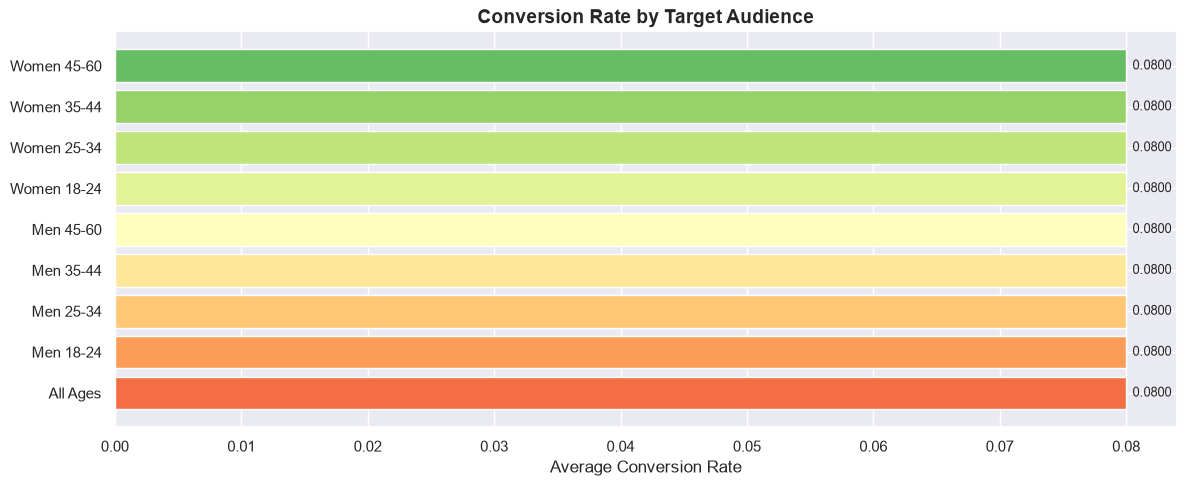

In [15]:
audience_stats = df.groupby('Target_Audience').agg(
    avg_conversion  = ('Conversion_Rate', 'mean'),
    avg_roi         = ('ROI',             'mean'),
    avg_engagement  = ('Engagement_Score','mean'),
    avg_cpc         = ('CPC',             'mean'),
    campaign_count  = ('Campaign_ID',     'count')
).round(3).sort_values('avg_conversion', ascending=False)

print("=== AUDIENCE PERFORMANCE RANKING ===")
print(audience_stats)

# Chart
plt.figure(figsize=(12, 5))
bars = plt.barh(audience_stats.index, audience_stats['avg_conversion'],
                color=plt.cm.RdYlGn(
                    np.linspace(0.2, 0.8, len(audience_stats))))
plt.title('Conversion Rate by Target Audience', fontsize=14, fontweight='bold')
plt.xlabel('Average Conversion Rate')
for bar, val in zip(bars, audience_stats['avg_conversion']):
    plt.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('audience_conversion.png', dpi=150, bbox_inches='tight')
plt.show()

=== CAMPAIGN GOAL PERFORMANCE ===
                  avg_roi  avg_engagement  avg_conversion  total_revenue  \
Campaign_Goal                                                              
Product Launch      3.190           4.374            0.08   1.850771e+09   
Increase Sales      3.179           4.374            0.08   1.845168e+09   
Brand Awareness     3.173           4.357            0.08   1.854696e+09   
Market Expansion    3.170           4.372            0.08   1.835806e+09   

                  count  
Campaign_Goal            
Product Launch    75030  
Increase Sales    74963  
Brand Awareness   75248  
Market Expansion  74759  


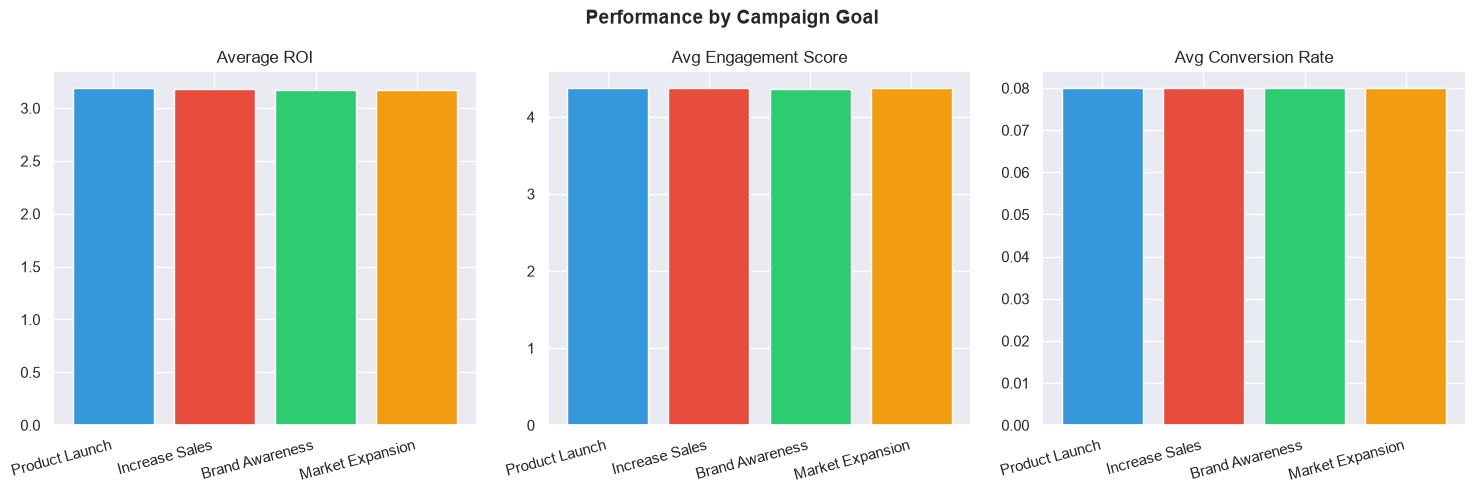

In [16]:
goal_stats = df.groupby('Campaign_Goal').agg(
    avg_roi         = ('ROI',             'mean'),
    avg_engagement  = ('Engagement_Score','mean'),
    avg_conversion  = ('Conversion_Rate', 'mean'),
    total_revenue   = ('Revenue',         'sum'),
    count           = ('Campaign_ID',     'count')
).round(3).sort_values('avg_roi', ascending=False)

print("=== CAMPAIGN GOAL PERFORMANCE ===")
print(goal_stats)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Performance by Campaign Goal', fontsize=14, fontweight='bold')

metrics = ['avg_roi', 'avg_engagement', 'avg_conversion']
titles  = ['Average ROI', 'Avg Engagement Score', 'Avg Conversion Rate']
colors  = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for ax, metric, title in zip(axes, metrics, titles):
    ax.bar(goal_stats.index, goal_stats[metric], color=colors)
    ax.set_title(title)
    ax.set_xticklabels(goal_stats.index, rotation=15, ha='right')

plt.tight_layout()
plt.savefig('campaign_goals.png', dpi=150, bbox_inches='tight')
plt.show()

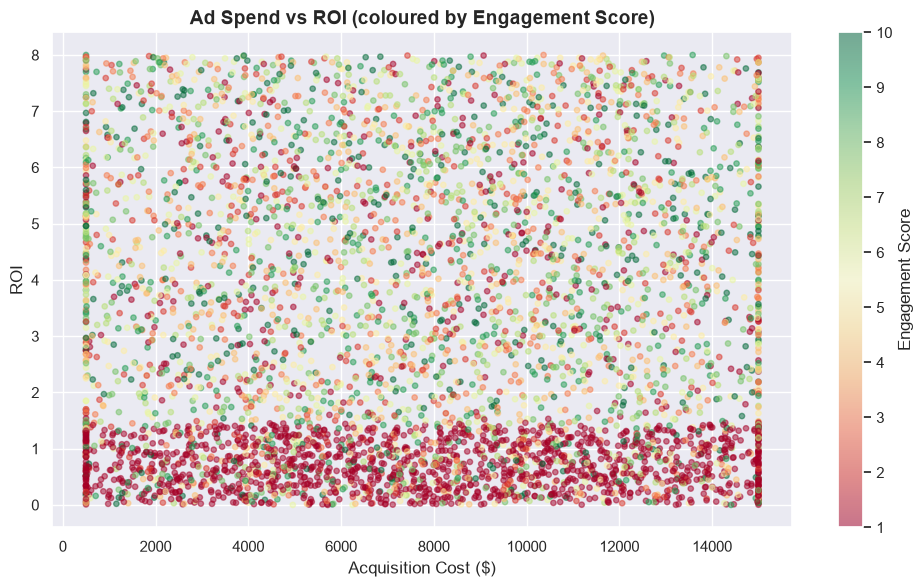

In [17]:
plt.figure(figsize=(10, 6))

# Sample 5000 points so chart isn't overcrowded
sample = df.sample(5000, random_state=42)

scatter = plt.scatter(sample['Acquisition_Cost'], sample['ROI'],
                      c=sample['Engagement_Score'],
                      cmap='RdYlGn', alpha=0.5, s=15)

plt.colorbar(scatter, label='Engagement Score')
plt.title('Ad Spend vs ROI (coloured by Engagement Score)',
          fontsize=14, fontweight='bold')
plt.xlabel('Acquisition Cost ($)')
plt.ylabel('ROI')
plt.tight_layout()
plt.savefig('spend_vs_roi.png', dpi=150, bbox_inches='tight')
plt.show()

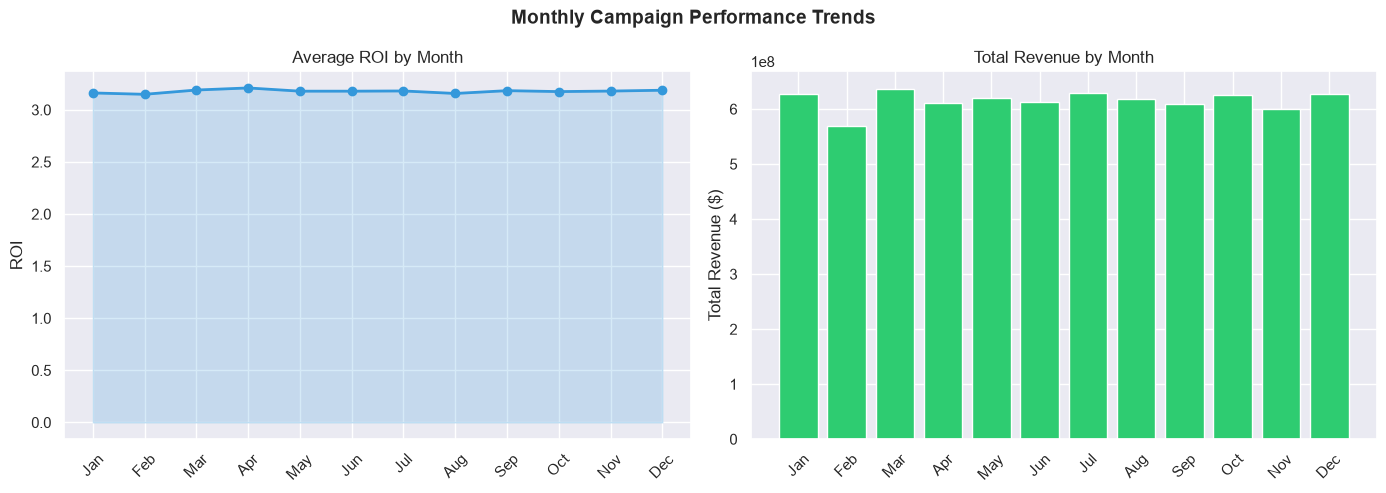

In [18]:
monthly = df.groupby('Month').agg(
    avg_roi        = ('ROI',             'mean'),
    avg_conversion = ('Conversion_Rate', 'mean'),
    total_revenue  = ('Revenue',         'sum'),
    campaigns      = ('Campaign_ID',     'count')
).round(3)

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly.index = month_names

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Monthly Campaign Performance Trends', fontsize=14, fontweight='bold')

axes[0].plot(monthly.index, monthly['avg_roi'],
             marker='o', color='#3498db', linewidth=2)
axes[0].fill_between(range(12), monthly['avg_roi'], alpha=0.2, color='#3498db')
axes[0].set_title('Average ROI by Month')
axes[0].set_ylabel('ROI')
axes[0].set_xticks(range(12))
axes[0].set_xticklabels(month_names, rotation=45)

axes[1].bar(monthly.index, monthly['total_revenue'],
            color='#2ecc71', edgecolor='white')
axes[1].set_title('Total Revenue by Month')
axes[1].set_ylabel('Total Revenue ($)')
axes[1].set_xticklabels(month_names, rotation=45)

plt.tight_layout()
plt.savefig('monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
print("=== DATASET QUALITY ASSESSMENT ===\n")

# Check variance in key metrics
metrics = ['Conversion_Rate', 'ROI', 'Engagement_Score', 'CTR']
print("Coefficient of Variation (higher = more interesting data):")
for m in metrics:
    cv = df[m].std() / df[m].mean() * 100
    print(f"  {m}: {cv:.1f}%")

# Check if conversion rate is truly uniform
print("\nConversion Rate unique values:", df['Conversion_Rate'].nunique())
print("ROI unique values:", df['ROI'].nunique())
print("Engagement Score unique values:", df['Engagement_Score'].nunique())

# Pinterest is the real outlier
print("\n=== KEY FINDING: PINTEREST UNDERPERFORMS ===")
pinterest = df[df['Channel_Used'] == 'Pinterest']
others    = df[df['Channel_Used'] != 'Pinterest']
print(f"Pinterest avg ROI:    {pinterest['ROI'].mean():.3f}")
print(f"Other platforms ROI:  {others['ROI'].mean():.3f}")
print(f"Pinterest avg engagement: {pinterest['Engagement_Score'].mean():.3f}")
print(f"Other platforms engagement: {others['Engagement_Score'].mean():.3f}")
print(f"\nPinterest revenue per campaign: ${pinterest['Revenue'].mean():,.2f}")
print(f"Other platforms revenue per campaign: ${others['Revenue'].mean():,.2f}")
print(f"\nConclusion: Pinterest campaigns generate {others['Revenue'].mean()/pinterest['Revenue'].mean():.1f}x less revenue than other platforms")

=== DATASET QUALITY ASSESSMENT ===

Coefficient of Variation (higher = more interesting data):
  Conversion_Rate: 50.7%
  ROI: 77.5%
  Engagement_Score: 72.2%
  CTR: 7.8%

Conversion Rate unique values: 15
ROI unique values: 1601
Engagement Score unique values: 10

=== KEY FINDING: PINTEREST UNDERPERFORMS ===
Pinterest avg ROI:    0.716
Other platforms ROI:  3.999
Pinterest avg engagement: 1.000
Other platforms engagement: 5.494

Pinterest revenue per campaign: $5,567.42
Other platforms revenue per campaign: $30,982.08

Conclusion: Pinterest campaigns generate 5.6x less revenue than other platforms


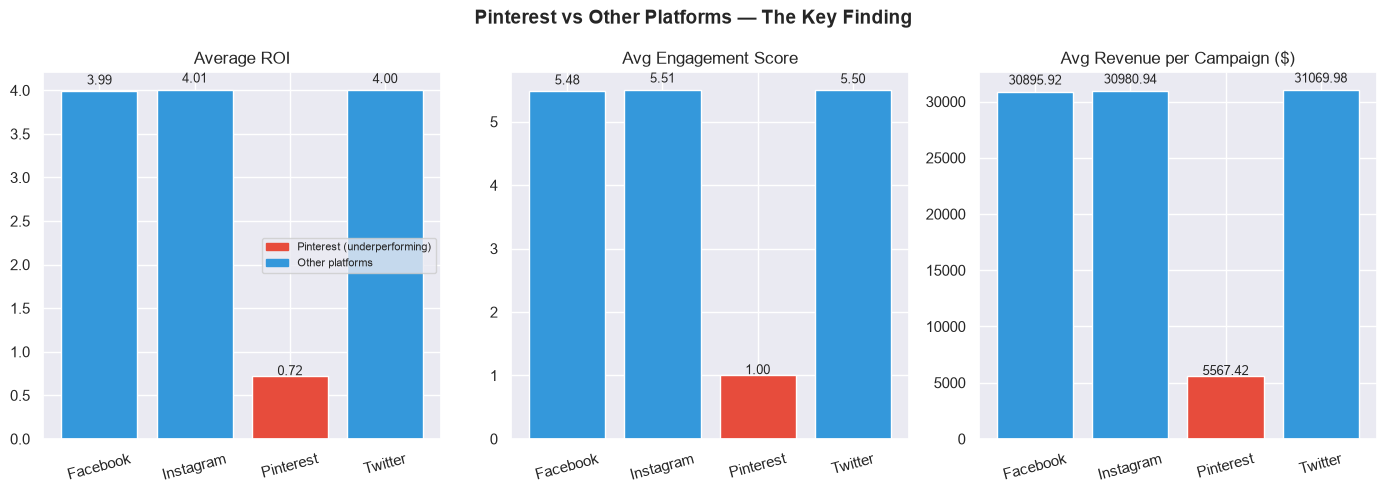

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Pinterest vs Other Platforms — The Key Finding',
             fontsize=14, fontweight='bold')

channels = df.groupby('Channel_Used')
metrics  = ['ROI', 'Engagement_Score', 'Revenue']
titles   = ['Average ROI', 'Avg Engagement Score', 'Avg Revenue per Campaign ($)']
colors   = ['#e74c3c' if c == 'Pinterest' else '#3498db'
            for c in df['Channel_Used'].unique()]

for ax, metric, title in zip(axes, metrics, titles):
    vals = df.groupby('Channel_Used')[metric].mean()
    bar_colors = ['#e74c3c' if c == 'Pinterest' else '#3498db'
                  for c in vals.index]
    bars = ax.bar(vals.index, vals.values, color=bar_colors)
    ax.set_title(title)
    ax.set_xticklabels(vals.index, rotation=15)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f'{val:.2f}', ha='center', fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend = [Patch(color='#e74c3c', label='Pinterest (underperforming)'),
          Patch(color='#3498db', label='Other platforms')]
axes[0].legend(handles=legend, fontsize=8)

plt.tight_layout()
plt.savefig('pinterest_vs_others.png', dpi=150, bbox_inches='tight')
plt.show()